In [2]:
from pathlib import Path
IMG_EXT = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

def show_tree(folder, depth=0, max_depth=4):
    folder = Path(folder)
    n = sum(1 for f in folder.rglob("*") if f.suffix.lower() in IMG_EXT)
    print("    " * depth + f"{folder.name}/  ({n} images)")
    if depth < max_depth:
        for sub in sorted(p for p in folder.iterdir() if p.is_dir()):
            show_tree(sub, depth + 1, max_depth)

show_tree("/kaggle/input")

input/  (6139 images)
    datasets/  (6139 images)
        bhanukachamindu/  (6139 images)
            aloe-colour/  (6107 images)
                Aloe_Vera_Dataset_Colour/  (6107 images)
            unseen-colour/  (32 images)
                Unseen_Test_Images_Colour/  (32 images)


In [4]:
import os, random, hashlib, math
from pathlib import Path
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
from PIL import Image

# ---------------- SETTINGS ----------------
TRAIN_DIR = "/kaggle/input/datasets/bhanukachamindu/aloe-colour"     # folder that contains (or holds, at any depth) the brown / green / yellow folders

MODEL_NAME = "EfficientNetB0"   # EfficientNetB0 | EfficientNetB1 | EfficientNetB2 | EfficientNetV2B0
BATCH = 32
EPOCHS_HEAD = 10        # phase 1: only the new classifier layer is trained
EPOCHS_FT = 25          # phase 2: the top of EfficientNet is fine-tuned too
UNFREEZE_LAST = 60      # how many EfficientNet layers to fine-tune in phase 2
LR_HEAD = 1e-3
LR_FT = 3e-5
SEED = 42
PREFIX = "colour"                        # start of the saved file names
POS_CLASS = "green"                  # used for the extra two-group check (lowercase class name)
POS_NAMES = ("good", "not good")       # names of the two groups: POS_CLASS vs everything else
OUT_DIR = "/kaggle/working"
WEIGHTS = "imagenet"
# ------------------------------------------

IMG_SIZES = {"EfficientNetB0": 224, "EfficientNetB1": 240, "EfficientNetB2": 260, "EfficientNetV2B0": 224}
IMG_SIZE = IMG_SIZES[MODEL_NAME]
IMG_EXT = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("TensorFlow", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU"))
print("Model:", MODEL_NAME, "| image size:", IMG_SIZE)

TensorFlow 2.20.0 | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Model: EfficientNetB0 | image size: 224


In [5]:
SPLIT_NAMES = {"train", "training", "val", "valid", "validation", "test", "testing"}

def norm(name):
    return name.strip().lower().replace("-", "_").replace(" ", "_")

def list_images(root):
    """All images under root. The class of a photo = name of the folder it sits in (lowercased)."""
    root = Path(root)
    assert root.exists(), f"Folder not found: {root}  (is the dataset added under Input? run the tree cell above)"
    paths, labels = [], []
    for f in sorted(root.rglob("*")):
        if f.is_file() and f.suffix.lower() in IMG_EXT:
            cls = norm(f.parent.name)
            if cls in SPLIT_NAMES:
                continue
            paths.append(str(f)); labels.append(cls)
    return paths, labels


print("Training folder:", TRAIN_DIR)
all_paths, all_labels = list_images(TRAIN_DIR)
CLASSES = sorted(set(all_labels))
class_to_idx = {c: i for i, c in enumerate(CLASSES)}
K = len(CLASSES); IDX = list(range(K))
counts = {c: all_labels.count(c) for c in CLASSES}
print("Classes found:", K)
for c in CLASSES:
    print(f"  {c:25s} {counts[c]:5d}  ({counts[c] / len(all_labels) * 100:4.1f}%)")
print("total:", len(all_paths))
assert 2 <= K <= 40, "Unexpected number of classes: check that TRAIN_DIR points at the folder holding the class folders."
assert min(counts.values()) >= 6, "A class has fewer than 6 photos, which is too few to split. Remove or merge it."

# 70 / 15 / 15 split, same class balance in every part
p_tr, p_tmp, y_tr, y_tmp = train_test_split(all_paths, all_labels, test_size=0.30, stratify=all_labels, random_state=SEED)
p_va, p_te, y_va, y_te = train_test_split(p_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)
print(f"\ntrain {len(p_tr)} | validation {len(p_va)} | test {len(p_te)}")

Training folder: /kaggle/input/datasets/bhanukachamindu/aloe-colour
Classes found: 3
  brown                       335  ( 5.5%)
  green                      1923  (31.5%)
  yellow                     3849  (63.0%)
total: 6107

train 4274 | validation 916 | test 917


In [6]:
def md5(p):
    with open(p, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

def ahash(p):
    im = Image.open(p).convert("L").resize((8, 8), Image.BILINEAR)
    a = np.asarray(im, dtype=float)
    return "".join("1" if v else "0" for v in (a > a.mean()).ravel())

def dup_report(name, paths, ref_md5, ref_ah):
    exact = sum(md5(p) in ref_md5 for p in paths)
    near = sum(ahash(p) in ref_ah for p in paths)
    print(f"{name:12s}: {exact:4d} exact copies | {near:4d} exact-or-near copies of a training photo (out of {len(paths)})")

tr_md5 = {md5(p) for p in p_tr}
tr_ah = {ahash(p) for p in p_tr}
dup_report("validation", p_va, tr_md5, tr_ah)
dup_report("test", p_te, tr_md5, tr_ah)
print("\nA large number means the validation/test scores are inflated.")

validation  :   18 exact copies |  197 exact-or-near copies of a training photo (out of 916)
test        :   13 exact copies |  170 exact-or-near copies of a training photo (out of 917)

A large number means the validation/test scores are inflated.


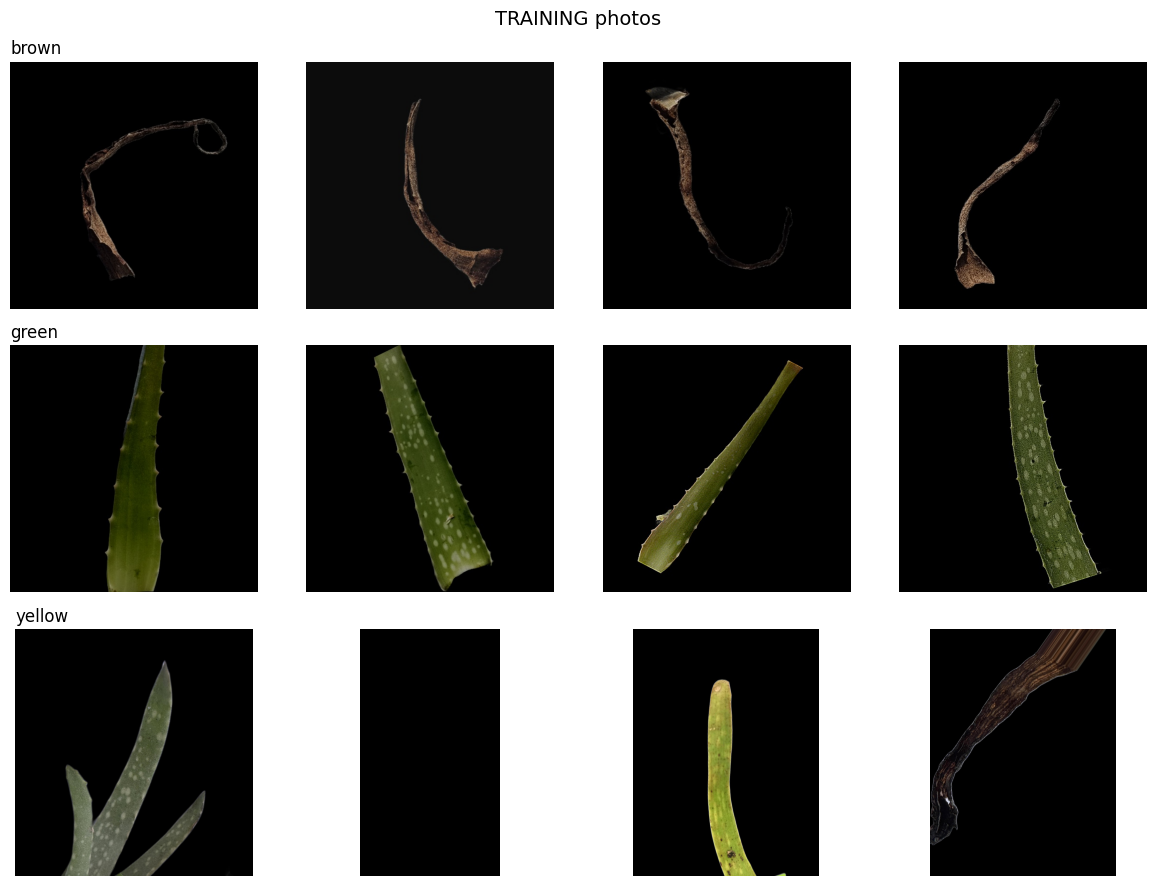

In [9]:
def show_samples(paths, labels, title, n=4, max_classes=8):
    cls = sorted(set(labels))[:max_classes]
    fig, axes = plt.subplots(len(cls), n, figsize=(3 * n, 3 * len(cls)), squeeze=False)
    rng = random.Random(1)
    for ax in axes.ravel():
        ax.axis("off")
    for r, c in enumerate(cls):
        pool = [p for p, l in zip(paths, labels) if l == c]
        for k, p in enumerate(rng.sample(pool, min(n, len(pool)))):
            axes[r][k].imshow(Image.open(p).convert("RGB"))
            if k == 0:
                axes[r][k].set_title(c, loc="left", fontsize=12)
    fig.suptitle(title, fontsize=14)
    plt.tight_layout(); plt.show()

show_samples(all_paths, all_labels, "TRAINING photos")

I0000 00:00:1789978165.038406      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789978165.044692      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


class weights: {'brown': 6.09, 'green': 1.06, 'yellow': 0.53}


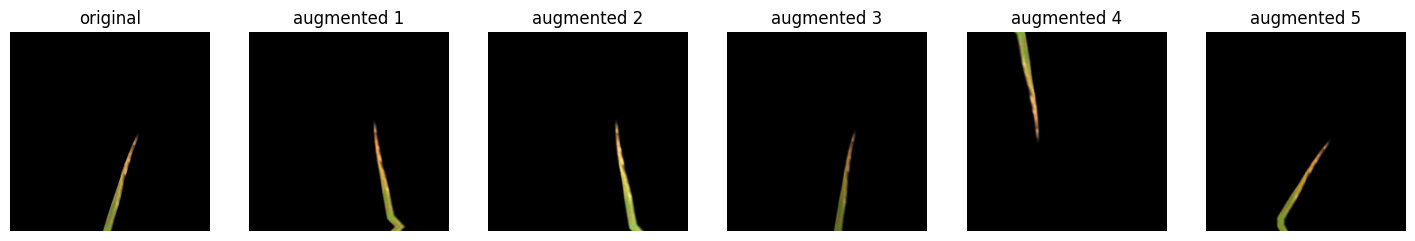

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

def load_img(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(tf.round(tf.clip_by_value(img, 0, 255)), tf.uint8)   # uint8 keeps the cache small
    return img, label

def to_float(img, label):
    return tf.cast(img, tf.float32), label

flip = layers.RandomFlip("horizontal_and_vertical")
rot  = layers.RandomRotation(0.08, fill_mode="reflect")
zoom = layers.RandomZoom((-0.25, 0.10), fill_mode="reflect")

def augment(img, label):
    x = tf.cast(img, tf.float32)
    x = flip(x, training=True)
    x = rot(x, training=True)
    x = zoom(x, training=True)
    x = x / 255.0
    x = x * tf.random.uniform([], 0.75, 1.25)                              # brightness
    x = tf.image.random_contrast(x, 0.8, 1.2)                               # contrast
    x = tf.image.random_saturation(tf.clip_by_value(x, 0, 1), 0.8, 1.2)     # saturation
    x = x * tf.random.uniform([3], 0.92, 1.08)                              # small colour cast (white balance)
    x = tf.clip_by_value(x, 0.0, 1.0) * 255.0
    return x, label

def make_ds(paths, labels, training):
    y = np.array([class_to_idx[l] for l in labels], dtype=np.int32)
    ds = tf.data.Dataset.from_tensor_slices((np.array(paths), y))
    ds = ds.map(load_img, num_parallel_calls=AUTOTUNE).cache()
    if training:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(to_float, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

train_ds = make_ds(p_tr, y_tr, training=True)
val_ds   = make_ds(p_va, y_va, training=False)

# common classes must not dominate: give rarer classes a bigger weight
cw = compute_class_weight("balanced", classes=np.arange(K), y=np.array([class_to_idx[l] for l in y_tr]))
class_weight = {i: float(w) for i, w in enumerate(cw)}
print("class weights:", {CLASSES[i]: round(w, 2) for i, w in class_weight.items()})

# quick look at what augmentation does to one photo
img0, _ = load_img(p_tr[0], 0)
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
axes[0].imshow(img0.numpy()); axes[0].set_title("original")
for k in range(1, 6):
    axes[k].imshow(augment(img0, 0)[0].numpy().astype("uint8")); axes[k].set_title(f"augmented {k}")
for a in axes: a.axis("off")
plt.show()

In [11]:
def build_model():
    Base = getattr(keras.applications, MODEL_NAME)
    base = Base(include_top=False, weights=WEIGHTS, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    inputs = keras.Input((IMG_SIZE, IMG_SIZE, 3))          # pixel values 0-255 (EfficientNet rescales inside)
    x = base(inputs, training=False)                       # keep BatchNorm in inference mode
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(K, activation="softmax")(x)
    return keras.Model(inputs, outputs, name=PREFIX + "_" + MODEL_NAME.lower()), base

model, base = build_model()
print("parameters:", f"{model.count_params():,}")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
parameters: 4,053,414


In [12]:
def callbacks(patience):
    return [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    ]

# ---------- Phase 1: classifier head only ----------
model.compile(optimizer=keras.optimizers.Adam(LR_HEAD),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
h1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD,
               class_weight=class_weight, callbacks=callbacks(patience=4))

Epoch 1/10


2026-09-21 08:11:09.862233: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 08:11:10.005777: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 08:11:10.363425: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 08:11:10.506713: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 08:11:11.394833: E external/local_xla/xla/stream_

133/134 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.7332 - loss: 0.5528

2026-09-21 08:11:51.791479: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 08:11:51.932489: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 08:11:52.274237: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 08:11:52.417247: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 08:11:53.303616: E external/local_xla/xla/stream_

134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.7340 - loss: 0.5512

2026-09-21 08:12:20.828199: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 08:12:20.969321: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 08:12:21.310070: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 08:12:21.464319: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 08:12:21.606220: E external/local_xla/xla/stream_

134/134 ━━━━━━━━━━━━━━━━━━━━ 132s 505ms/step - accuracy: 0.8397 - loss: 0.3487 - val_accuracy: 0.9356 - val_loss: 0.2017 - learning_rate: 0.0010
Epoch 2/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 28s 206ms/step - accuracy: 0.9359 - loss: 0.1483 - val_accuracy: 0.9520 - val_loss: 0.1616 - learning_rate: 0.0010
Epoch 3/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 28s 205ms/step - accuracy: 0.9483 - loss: 0.1179 - val_accuracy: 0.9596 - val_loss: 0.1208 - learning_rate: 0.0010
Epoch 4/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 27s 203ms/step - accuracy: 0.9619 - loss: 0.0919 - val_accuracy: 0.9541 - val_loss: 0.1403 - learning_rate: 0.0010
Epoch 5/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 28s 206ms/step - accuracy: 0.9593 - loss: 0.0852 - val_accuracy: 0.9672 - val_loss: 0.1006 - learning_rate: 0.0010
Epoch 6/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 28s 205ms/step - accuracy: 0.9663 - loss: 0.0743 - val_accuracy: 0.9683 - val_loss: 0.0873 - learning_rate: 0.0010
Epoch 7/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 28s 206ms/step - accuracy: 0.9701 - loss

In [13]:
# ---------- Phase 2: fine-tune the top of EfficientNet ----------
base.trainable = True
for layer in base.layers[:-UNFREEZE_LAST]:
    layer.trainable = False
for layer in base.layers:
    if isinstance(layer, layers.BatchNormalization):     # never fine-tune BatchNorm statistics
        layer.trainable = False
print("trainable parameters:", f"{sum(int(np.prod(w.shape)) for w in model.trainable_weights):,}")

model.compile(optimizer=keras.optimizers.Adam(LR_FT),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
h2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FT,
               class_weight=class_weight, callbacks=callbacks(patience=6))

trainable parameters: 2,653,123
Epoch 1/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 85s 409ms/step - accuracy: 0.9782 - loss: 0.0445 - val_accuracy: 0.9825 - val_loss: 0.0554 - learning_rate: 3.0000e-05
Epoch 2/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 29s 217ms/step - accuracy: 0.9846 - loss: 0.0318 - val_accuracy: 0.9967 - val_loss: 0.0178 - learning_rate: 3.0000e-05
Epoch 3/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 29s 217ms/step - accuracy: 0.9890 - loss: 0.0232 - val_accuracy: 0.9934 - val_loss: 0.0170 - learning_rate: 3.0000e-05
Epoch 4/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 29s 217ms/step - accuracy: 0.9904 - loss: 0.0195 - val_accuracy: 0.9978 - val_loss: 0.0083 - learning_rate: 3.0000e-05
Epoch 5/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 29s 216ms/step - accuracy: 0.9871 - loss: 0.0194 - val_accuracy: 0.9945 - val_loss: 0.0144 - learning_rate: 3.0000e-05
Epoch 6/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 29s 216ms/step - accuracy: 0.9949 - loss: 0.0107 - val_accuracy: 0.9978 - val_loss: 0.0072 - learning_rate: 3.0000e-05
Epoch 7/25
134

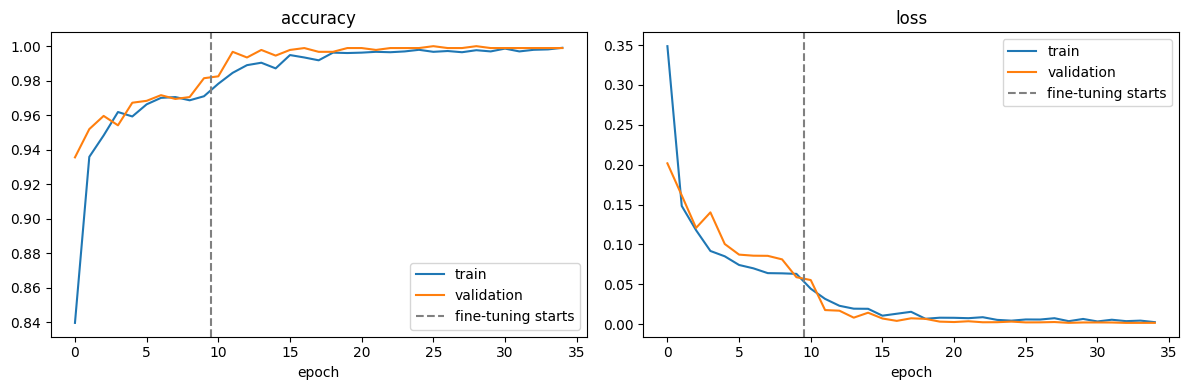

In [14]:
acc  = h1.history["accuracy"] + h2.history["accuracy"]
vacc = h1.history["val_accuracy"] + h2.history["val_accuracy"]
loss = h1.history["loss"] + h2.history["loss"]
vloss = h1.history["val_loss"] + h2.history["val_loss"]
split = len(h1.history["loss"])
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, (tr, va, name) in zip(ax, [(acc, vacc, "accuracy"), (loss, vloss, "loss")]):
    a.plot(tr, label="train"); a.plot(va, label="validation")
    a.axvline(split - 0.5, color="grey", ls="--", label="fine-tuning starts")
    a.set_title(name); a.set_xlabel("epoch"); a.legend()
plt.tight_layout(); plt.show()

2026-09-21 08:31:09.967733: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 08:31:10.109392: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 08:31:10.458566: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 08:31:10.601955: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 08:31:11.460426: E external/local_xla/xla/stream_


===== HELD-OUT TEST split: accuracy 99.78% | macro F1 0.998 =====

              precision    recall  f1-score   support

       brown      1.000     1.000     1.000        50
       green      0.993     1.000     0.997       289
      yellow      1.000     0.997     0.998       578

    accuracy                          0.998       917
   macro avg      0.998     0.999     0.998       917
weighted avg      0.998     0.998     0.998       917

How often each class really occurs vs how often the model predicts it
(one class predicted far more than it occurs = the model is falling back on it):
  brown                     true   50 | predicted   50
  green                     true  289 | predicted  291
  yellow                    true  578 | predicted  576

Most common mix-ups (count: true -> predicted):
     2: yellow -> green

confusion matrix (rows = true, columns = predicted): ['brown', 'green', 'yellow']
[[ 50   0   0]
 [  0 289   0]
 [  0   2 576]]


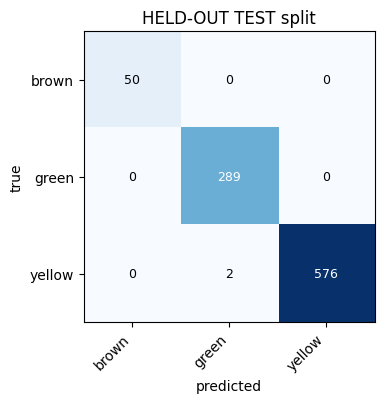


Good vs not good accuracy: 99.78%
'not good' photos called GOOD: 2 of 628
'good' photos called NOT GOOD: 0 of 289
(Always answering 'not good' would score 68.5%)


In [15]:
def plot_cm(cm, title):
    size = max(4.6, 0.65 * K + 2.5)
    fig, ax = plt.subplots(figsize=(size, size * 0.9))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(IDX); ax.set_xticklabels(CLASSES, rotation=45, ha="right")
    ax.set_yticks(IDX); ax.set_yticklabels(CLASSES)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(title)
    for i in IDX:
        for j in IDX:
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=9,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.tight_layout(); plt.show()

def binary_check(y, pred):
    if POS_CLASS not in class_to_idx:
        return
    a, b = POS_NAMES
    g = class_to_idx[POS_CLASS]
    t, p = (y == g), (pred == g)
    print(f"\n{a.capitalize()} vs {b} accuracy: {(t == p).mean() * 100:.2f}%")
    print(f"'{b}' photos called {a.upper()}: {int(((~t) & p).sum())} of {int((~t).sum())}")
    print(f"'{a}' photos called {b.upper()}: {int((t & ~p).sum())} of {int(t.sum())}")
    print(f"(Always answering '{b}' would score {(~t).mean() * 100:.1f}%)")

def report(y, pred, name):
    """Accuracy, per-class report, how often each class is predicted, main mix-ups, confusion matrix."""
    acc = accuracy_score(y, pred)
    f1 = f1_score(y, pred, average="macro", labels=sorted(set(y)), zero_division=0)
    print(f"\n===== {name}: accuracy {acc * 100:.2f}% | macro F1 {f1:.3f} =====\n")
    print(classification_report(y, pred, labels=IDX, target_names=CLASSES, digits=3, zero_division=0))
    print("How often each class really occurs vs how often the model predicts it")
    print("(one class predicted far more than it occurs = the model is falling back on it):")
    for i, c in enumerate(CLASSES):
        print(f"  {c:25s} true {int((y == i).sum()):4d} | predicted {int((pred == i).sum()):4d}")
    cm = confusion_matrix(y, pred, labels=IDX)
    pairs = sorted(((cm[i, j], CLASSES[i], CLASSES[j]) for i in IDX for j in IDX if i != j and cm[i, j] > 0), reverse=True)[:8]
    if pairs:
        print("\nMost common mix-ups (count: true -> predicted):")
        for n, a, b in pairs:
            print(f"  {n:4d}: {a} -> {b}")
    print("\nconfusion matrix (rows = true, columns = predicted):", CLASSES)
    print(cm)
    plot_cm(cm, name)
    binary_check(y, pred)
    return acc, f1

probs_t = model.predict(make_ds(p_te, y_te, training=False), verbose=0)
pred_t = probs_t.argmax(1)
y_t = np.array([class_to_idx[l] for l in y_te])
test_acc, test_f1 = report(y_t, pred_t, "HELD-OUT TEST split")

In [16]:
model_file  = f"{OUT_DIR}/{PREFIX}_{MODEL_NAME.lower()}.keras"
labels_file = f"{OUT_DIR}/{PREFIX}_{MODEL_NAME.lower()}_labels.txt"
model.save(model_file)
Path(labels_file).write_text("\n".join(CLASSES))
print("saved:", model_file, "\nsaved:", labels_file)

print("\n================ SUMMARY ================")
print(f"model         : {MODEL_NAME}   ({K} classes)")
print(f"held-out test : accuracy {test_acc * 100:.2f}% | macro F1 {test_f1:.3f}")
print("\nNext: Save Version -> Save & Run All (Commit), then open the second notebook (unseen evaluation).")

saved: /kaggle/working/colour_efficientnetb0.keras 
saved: /kaggle/working/colour_efficientnetb0_labels.txt

================ SUMMARY ================
model         : EfficientNetB0   (3 classes)
held-out test : accuracy 99.78% | macro F1 0.998

Next: Save Version -> Save & Run All (Commit), then open the second notebook (unseen evaluation).


In [17]:
import os, zipfile
from pathlib import Path
from IPython.display import FileLink, display

# find the newest colour EfficientNet model (works in the training or in the evaluation notebook)
found = [p for root in ["/kaggle/working", "/kaggle/input"] for p in Path(root).rglob("colour_efficientnet*.keras")]
assert found, "No colour_efficientnet*.keras model found. Run the training notebook first, or add it as an input."
model = max(found, key=lambda p: p.stat().st_mtime)
labels = model.with_name(model.stem + "_labels.txt")

os.chdir("/kaggle/working")
zip_name = "aloe_colour_model.zip"
with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as z:
    for f in [model, labels]:
        if f.exists():
            z.write(f, arcname=f.name)
print("Zipped:", zipfile.ZipFile(zip_name).namelist(), f"({Path(zip_name).stat().st_size / 1e6:.1f} MB)")
display(FileLink(zip_name))

Zipped: ['colour_efficientnetb0.keras', 'colour_efficientnetb0_labels.txt'] (34.9 MB)


/kaggle/working/aloe_colour_model.zip